# Diabetes Risk Prediction — Model Training

Trains and evaluates 4 ensemble ML models on preprocessed hospital data.

**Models:**
1. Random Forest (Bagging ensemble)
2. Gradient Boosting (Boosting ensemble)
3. AdaBoost (Boosting ensemble)
4. Voting Classifier (Combined ensemble)

**Target Classes:**
- 0 = Low Risk (not readmitted)
- 1 = Medium Risk (readmitted >30 days)
- 2 = High Risk (readmitted <30 days)

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    VotingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Load Preprocessed Data

Load the artefacts saved by the preprocessing notebook.

In [2]:
X_train_resampled = joblib.load('../models/X_train_resampled.pkl')
y_train_resampled = joblib.load('../models/y_train_resampled.pkl')
X_test_scaled     = joblib.load('../models/X_test_scaled.pkl')
y_test            = joblib.load('../models/y_test.pkl')

print('X_train_resampled shape:', X_train_resampled.shape)
print('y_train_resampled shape:', y_train_resampled.shape)
print('X_test_scaled     shape:', X_test_scaled.shape)
print('y_test            shape:', y_test.shape)
print()
print('Training class distribution (balanced):')
print(pd.Series(y_train_resampled).value_counts())

X_train_resampled shape: (131673, 103)
y_train_resampled shape: (131673,)
X_test_scaled     shape: (20354, 103)
y_test            shape: (20354,)

Training class distribution (balanced):
readmitted
0    43891
2    43891
1    43891
Name: count, dtype: int64


## Model 1 — Random Forest

**Type:** Bagging ensemble

Builds many independent decision trees, each trained on a random subset of data and features.
Final prediction = majority vote across all trees.

**Strengths:** Handles high-dimensional data, robust to noise, provides feature importance.

In [3]:
print('Training Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_model.fit(X_train_resampled, y_train_resampled)

print('Random Forest trained.')

Training Random Forest...


Random Forest trained.


In [4]:
rf_predictions = rf_model.predict(X_test_scaled)
rf_accuracy    = accuracy_score(y_test, rf_predictions)

print(f'Random Forest Accuracy: {rf_accuracy:.4f} ({rf_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(
    y_test,
    rf_predictions,
    target_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
))

Random Forest Accuracy: 0.5756 (57.56%)

Classification Report:
                 precision    recall  f1-score   support

   Low Risk (0)       0.62      0.81      0.70     10973
Medium Risk (1)       0.49      0.38      0.43      7109
  High Risk (2)       0.27      0.05      0.09      2272

       accuracy                           0.58     20354
      macro avg       0.46      0.41      0.40     20354
   weighted avg       0.53      0.58      0.54     20354



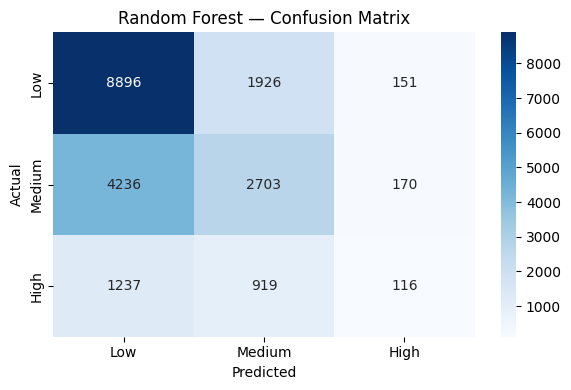

In [5]:
plt.figure(figsize=(6, 4))

cm = confusion_matrix(y_test, rf_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/plots/rf_confusion_matrix.png')
plt.show()

## Model 2 — Gradient Boosting

**Type:** Sequential boosting ensemble

Builds trees one by one — each tree corrects the errors of the previous tree.
Learns from mistakes iteratively.

**Strengths:** Very high accuracy, handles complex non-linear patterns.

In [6]:
print('Training Gradient Boosting...')

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train_resampled, y_train_resampled)

print('Gradient Boosting trained.')

Training Gradient Boosting...


Gradient Boosting trained.


In [7]:
gb_predictions = gb_model.predict(X_test_scaled)
gb_accuracy    = accuracy_score(y_test, gb_predictions)

print(f'Gradient Boosting Accuracy: {gb_accuracy:.4f} ({gb_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(
    y_test,
    gb_predictions,
    target_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
))

Gradient Boosting Accuracy: 0.5873 (58.73%)

Classification Report:
                 precision    recall  f1-score   support

   Low Risk (0)       0.62      0.84      0.71     10973
Medium Risk (1)       0.51      0.37      0.43      7109
  High Risk (2)       0.39      0.05      0.09      2272

       accuracy                           0.59     20354
      macro avg       0.50      0.42      0.41     20354
   weighted avg       0.55      0.59      0.54     20354



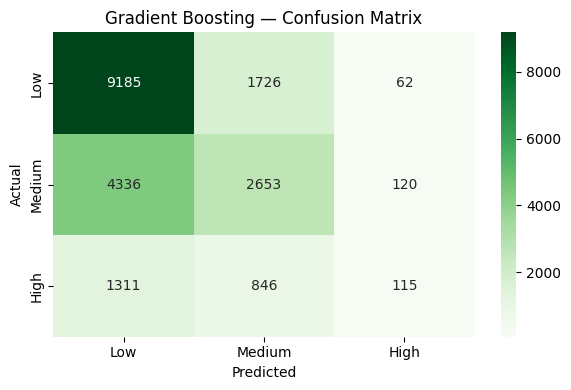

In [8]:
plt.figure(figsize=(6, 4))

cm = confusion_matrix(y_test, gb_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Gradient Boosting — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/plots/gb_confusion_matrix.png')
plt.show()

## Model 3 — AdaBoost

**Type:** Adaptive boosting ensemble

Sequentially trains weak classifiers (shallow trees).
Misclassified samples get higher weight in the next iteration — forcing the model to focus on hard cases.

**Strengths:** Lightweight, fast training, good for imbalanced problems.

In [9]:
print('Training AdaBoost...')

ab_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.5,
    algorithm='SAMME',
    random_state=42
)

ab_model.fit(X_train_resampled, y_train_resampled)

print('AdaBoost trained.')

Training AdaBoost...


AdaBoost trained.


In [10]:
ab_predictions = ab_model.predict(X_test_scaled)
ab_accuracy    = accuracy_score(y_test, ab_predictions)

print(f'AdaBoost Accuracy: {ab_accuracy:.4f} ({ab_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(
    y_test,
    ab_predictions,
    target_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
))

AdaBoost Accuracy: 0.5255 (52.55%)

Classification Report:
                 precision    recall  f1-score   support

   Low Risk (0)       0.62      0.71      0.66     10973
Medium Risk (1)       0.45      0.34      0.39      7109
  High Risk (2)       0.19      0.22      0.20      2272

       accuracy                           0.53     20354
      macro avg       0.42      0.42      0.42     20354
   weighted avg       0.52      0.53      0.52     20354



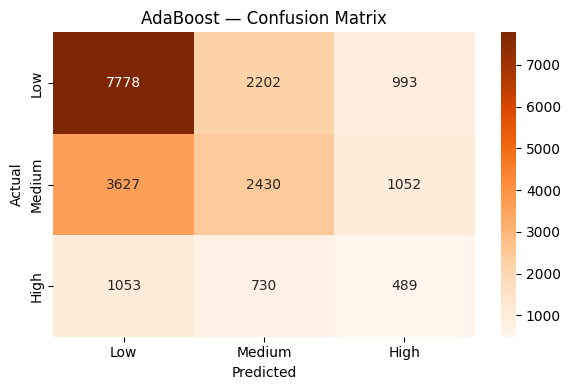

In [11]:
plt.figure(figsize=(6, 4))

cm = confusion_matrix(y_test, ab_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('AdaBoost — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/plots/ab_confusion_matrix.png')
plt.show()

## Model 4 — Voting Classifier

**Type:** Meta-ensemble (combines multiple models)

Combines RF + GB + AdaBoost predictions via majority vote.
If 2+ models agree on a class → that becomes the final prediction.

**Strengths:** Reduces individual model weaknesses, often best overall accuracy.

In [12]:
print('Training Voting Classifier (combines RF + GB + AdaBoost)...')

voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('ab', ab_model)
    ],
    voting='hard'
)

voting_model.fit(X_train_resampled, y_train_resampled)

print('Voting Classifier trained.')

Training Voting Classifier (combines RF + GB + AdaBoost)...


Voting Classifier trained.


In [13]:
voting_predictions = voting_model.predict(X_test_scaled)
voting_accuracy    = accuracy_score(y_test, voting_predictions)

print(f'Voting Classifier Accuracy: {voting_accuracy:.4f} ({voting_accuracy*100:.2f}%)')
print()
print('Classification Report:')
print(classification_report(
    y_test,
    voting_predictions,
    target_names=['Low Risk (0)', 'Medium Risk (1)', 'High Risk (2)']
))

Voting Classifier Accuracy: 0.5775 (57.75%)

Classification Report:
                 precision    recall  f1-score   support

   Low Risk (0)       0.62      0.82      0.70     10973
Medium Risk (1)       0.50      0.37      0.42      7109
  High Risk (2)       0.27      0.06      0.09      2272

       accuracy                           0.58     20354
      macro avg       0.46      0.42      0.41     20354
   weighted avg       0.54      0.58      0.54     20354



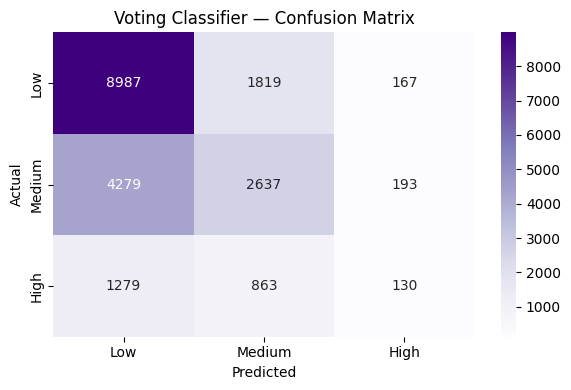

In [14]:
plt.figure(figsize=(6, 4))

cm = confusion_matrix(y_test, voting_predictions)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Voting Classifier — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../outputs/plots/voting_confusion_matrix.png')
plt.show()

## Compare All Models

Side-by-side accuracy comparison.

In [15]:
results = pd.DataFrame({
    'Model': [
        'Random Forest',
        'Gradient Boosting',
        'AdaBoost',
        'Voting Classifier'
    ],
    'Accuracy': [
        rf_accuracy,
        gb_accuracy,
        ab_accuracy,
        voting_accuracy
    ],
    'Accuracy (%)': [
        f'{rf_accuracy*100:.2f}%',
        f'{gb_accuracy*100:.2f}%',
        f'{ab_accuracy*100:.2f}%',
        f'{voting_accuracy*100:.2f}%'
    ]
})

results_sorted = results.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print('Model Accuracy Comparison:')
print(results_sorted[['Model', 'Accuracy (%)']])

Model Accuracy Comparison:
               Model Accuracy (%)
0  Gradient Boosting       58.73%
1  Voting Classifier       57.75%
2      Random Forest       57.56%
3           AdaBoost       52.55%


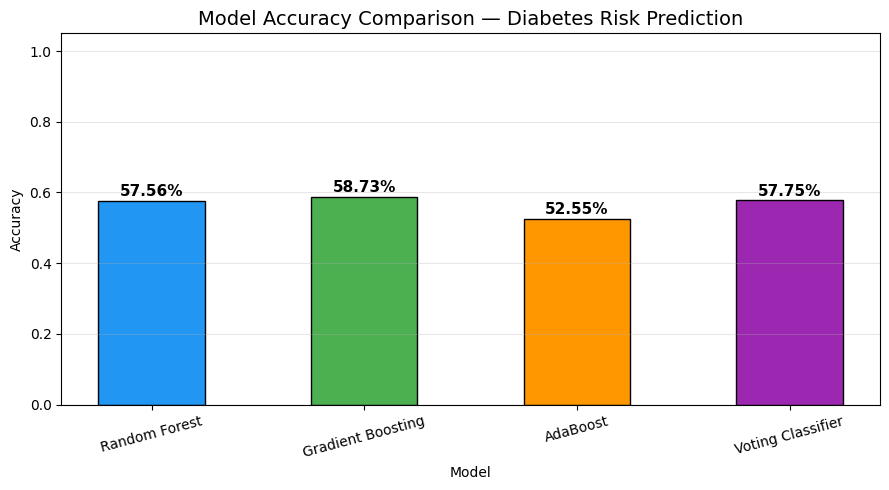

In [16]:
plt.figure(figsize=(9, 5))

bars = plt.bar(
    results['Model'],
    results['Accuracy'],
    color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'],
    edgecolor='black',
    width=0.5
)

for bar, acc in zip(bars, results['Accuracy']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f'{acc*100:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title('Model Accuracy Comparison — Diabetes Risk Prediction', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/plots/model_comparison.png')
plt.show()

## Feature Importance (Random Forest)

Which patient features have the most impact on readmission risk?

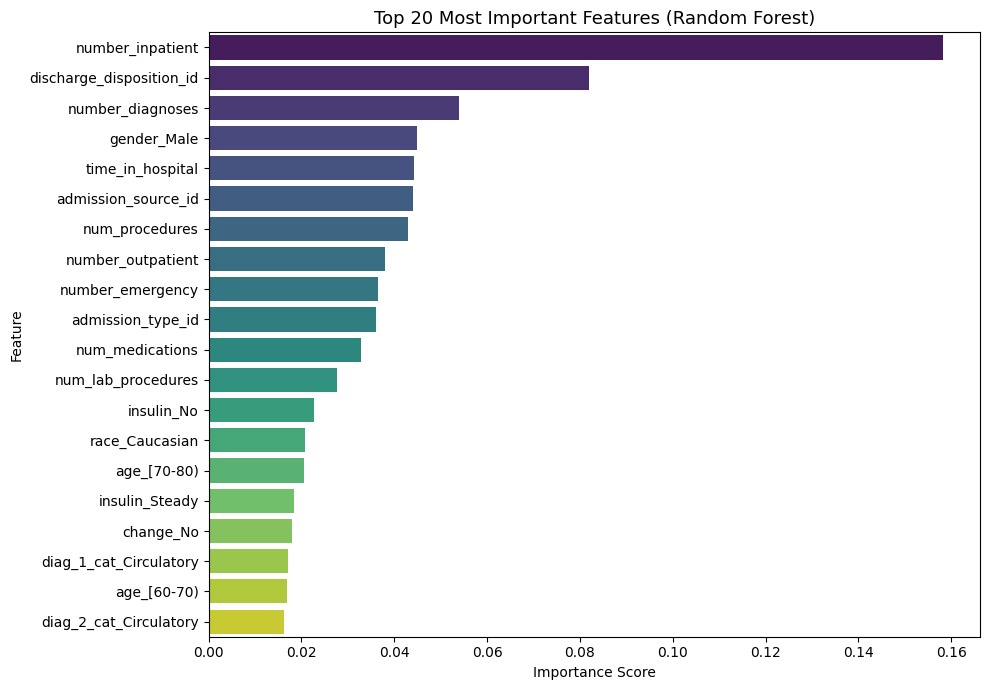

Top 10 Features:
                 Feature  Importance
        number_inpatient    0.158277
discharge_disposition_id    0.081992
        number_diagnoses    0.053968
             gender_Male    0.044962
        time_in_hospital    0.044337
     admission_source_id    0.043973
          num_procedures    0.042889
       number_outpatient    0.037955
        number_emergency    0.036410
       admission_type_id    0.035996


In [17]:
feature_cols = joblib.load('../models/feature_columns.pkl')

importances = rf_model.feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feat_df,
    palette='viridis'
)

plt.title('Top 20 Most Important Features (Random Forest)', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/plots/feature_importance.png')
plt.show()

print('Top 10 Features:')
print(feat_df[['Feature', 'Importance']].head(10).to_string(index=False))

## Save Best Model

Select and save the best-performing model for the prediction API.

In [18]:
os.makedirs('../models', exist_ok=True)

# Determine best model by accuracy
model_scores = {
    'Random Forest':    rf_accuracy,
    'Gradient Boosting': gb_accuracy,
    'AdaBoost':         ab_accuracy,
    'Voting Classifier': voting_accuracy
}

best_name = max(model_scores, key=model_scores.get)
best_acc  = model_scores[best_name]

print(f'Best model: {best_name} ({best_acc*100:.2f}%)')

# Save the Voting Classifier as production model
# (it combines all models for the most robust predictions)
joblib.dump(voting_model, '../models/best_model.pkl')

# Also save individual models
joblib.dump(rf_model,     '../models/rf_model.pkl')
joblib.dump(gb_model,     '../models/gb_model.pkl')
joblib.dump(ab_model,     '../models/ab_model.pkl')

print()
print('Saved models:')
print('  ../models/best_model.pkl  (Voting Classifier — production)')
print('  ../models/rf_model.pkl')
print('  ../models/gb_model.pkl')
print('  ../models/ab_model.pkl')
print()
print('Model training complete! System is ready for API integration.')

Best model: Gradient Boosting (58.73%)



Saved models:
  ../models/best_model.pkl  (Voting Classifier — production)
  ../models/rf_model.pkl
  ../models/gb_model.pkl
  ../models/ab_model.pkl

Model training complete! System is ready for API integration.


## Summary

### What the model learned:
- Patterns in hospital stay duration, medications, diagnoses, and patient demographics
- Which combinations of features indicate high readmission risk

### Artefacts ready for API:
| File | Purpose |
|---|---|
| `best_model.pkl` | Main prediction model |
| `scaler.pkl` | Normalize new patient data |
| `feature_columns.pkl` | Align API input to training features |

### Risk Classes:
| Code | Meaning |
|---|---|
| 0 | Low Risk — Not readmitted |
| 1 | Medium Risk — Readmitted after 30 days |
| 2 | High Risk — Readmitted within 30 days |